# Quora Duplicate Question Detection

## Classical Machine Learning Models

This notebook trains and evaluates classical supervised models using the
preprocessed datasets created in `01_data_preparation_eda.ipynb`.

## Project Setup and Imports

In [1]:
try:
    from google.colab import drive

    drive.mount("/content/drive")
except ImportError:
    pass

Mounted at /content/drive


In [2]:
%cd "/content/drive/MyDrive/ML Projects/quora-duplicate-question-detection"

/content/drive/MyDrive/ML Projects/quora-duplicate-question-detection


In [3]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /content/drive/MyDrive/ML Projects/quora-duplicate-question-detection


In [4]:
import pandas as pd
import numpy as np
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from src.config import (
    processed_train_file,
    processed_test_file,
    results_file,
)
from src.evaluation import evaluate_binary_classifier

import os

In [5]:
RANDOMSEED = 42

## TF-IDF + Logistic Regression

### Load Preprocessed Data

In [6]:
processed_train = pd.read_parquet(
    processed_train_file
)

processed_test = pd.read_parquet(
    processed_test_file
)

train_data = (
    processed_train[
        processed_train["split"] == "train"
    ]
    .copy()
)

valid_data = (
    processed_train[
        processed_train["split"] == "valid"
    ]
    .copy()
)

print("Train shape:", train_data.shape)
print("Validation shape:", valid_data.shape)
print("Test shape:", processed_test.shape)

Train shape: (258743, 11)
Validation shape: (64686, 11)
Test shape: (80858, 10)


In [7]:
y_train = train_data["is_duplicate"].astype(int)
y_valid = valid_data["is_duplicate"].astype(int)

### TF-IDF Feature Construction

In [8]:
tfidf_vectorizer = TfidfVectorizer(
    lowercase=False,
    analyzer="word",
    token_pattern=r"(?u)\b\w+\b",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    norm="l2",
    dtype=np.float32
)

In [9]:
train_q1 = train_data["question1_tfidf"].fillna("")
train_q2 = train_data["question2_tfidf"].fillna("")

valid_q1 = valid_data["question1_tfidf"].fillna("")
valid_q2 = valid_data["question2_tfidf"].fillna("")

In [10]:
train_corpus = pd.concat(
    [
        train_q1,
        train_q2
    ],
    ignore_index=True
)

tfidf_vectorizer.fit(train_corpus)

TfidfVectorizer(dtype=<class 'numpy.float32'>, lowercase=False, max_df=0.95,
                min_df=2, ngram_range=(1, 2), sublinear_tf=True,
                token_pattern='(?u)\\b\\w+\\b')

In [11]:
print(
    f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_):,}"
)

Vocabulary size: 342,949


In [12]:
X_train_q1 = tfidf_vectorizer.transform(train_q1)
X_train_q2 = tfidf_vectorizer.transform(train_q2)

X_valid_q1 = tfidf_vectorizer.transform(valid_q1)
X_valid_q2 = tfidf_vectorizer.transform(valid_q2)

In [13]:
X_train_diff = abs(X_train_q1 - X_train_q2)
X_valid_diff = abs(X_valid_q1 - X_valid_q2)

X_train_product = X_train_q1.multiply(X_train_q2)
X_valid_product = X_valid_q1.multiply(X_valid_q2)

X_train_pair = hstack(
    [X_train_diff, X_train_product],
    format="csr"
)

X_valid_pair = hstack(
    [X_valid_diff, X_valid_product],
    format="csr"
)

print("Train pair shape:", X_train_pair.shape)
print("Validation pair shape:", X_valid_pair.shape)

Train pair shape: (258743, 685898)
Validation pair shape: (64686, 685898)


### Logistic Regression Training and Evaluation

In [14]:
tfidf_lr = LogisticRegression(
    solver="saga",
    max_iter=300,
    random_state=RANDOMSEED,
    verbose=1
)

In [ ]:
tfidf_lr.fit(
    X_train_pair,
    y_train
)

valid_pred = tfidf_lr.predict(X_valid_pair)
valid_proba = tfidf_lr.predict_proba(X_valid_pair)[:, 1]

Model: TF-IDF + Logistic Regression

              precision    recall  f1-score   support

           0     0.8372    0.8977    0.8664     40804
           1     0.8005    0.7017    0.7478     23882

    accuracy                         0.8253     64686
   macro avg     0.8189    0.7997    0.8071     64686
weighted avg     0.8236    0.8253    0.8226     64686

accuracy: 0.8253
precision: 0.8005
recall: 0.7017
f1: 0.7478
roc_auc: 0.9039
log_loss: 0.3893


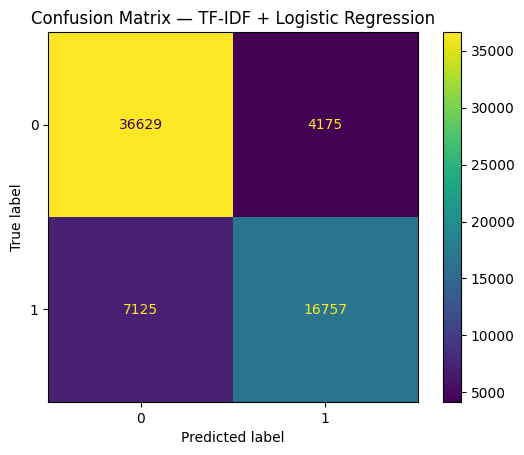

In [16]:
tfidf_lr_metrics = evaluate_binary_classifier(
    model_name="TF-IDF + Logistic Regression",
    y_true=y_valid,
    y_pred=valid_pred,
    y_proba=valid_proba,
)

### Conclusions

- TF-IDF combined with Logistic Regression provides a strong supervised baseline for duplicate-question detection.
- The model achieved a validation ROC-AUC of approximately **0.90**, demonstrating a strong ability to distinguish duplicate and non-duplicate question pairs.
- Precision and recall are reasonably balanced, resulting in a positive-class F1-score of approximately **0.75**.
- The use of both unigram and bigram TF-IDF features allowed the model to capture both lexical overlap and short phrase similarity between questions.
- This model will serve as the baseline for comparison with more advanced approaches in the subsequent experiments.

### Experiment Results

The validation metrics of each model experiment are stored in a shared results
table. Re-running the same experiment replaces its previous result instead of
creating duplicate rows.

In [17]:
result_row = {
    "experiment_id": "tfidf_logreg_baseline",
    "evaluation_split": "validation",
    "feature_set": (
        "TF-IDF word 1-2 grams: "
        "absolute difference + element-wise product"
    ),
    "threshold": 0.5,
    **tfidf_lr_metrics,
}

current_result = pd.DataFrame(
    [result_row]
)

In [18]:
os.makedirs(
    os.path.dirname(results_file),
    exist_ok=True,
)

if os.path.exists(results_file):
    model_results = pd.read_csv(
        results_file
    )

    model_results = model_results[
        model_results["experiment_id"]
        != result_row["experiment_id"]
    ]

    model_results = pd.concat(
        [
            model_results,
            current_result,
        ],
        ignore_index=True,
    )

else:
    model_results = current_result.copy()

In [19]:
model_results.to_csv(
    results_file,
    index=False,
)

print(f"Results saved to: {results_file}")

Results saved to: /content/drive/MyDrive/ML Projects/quora-duplicate-question-detection/reports/model_results.csv


In [20]:
model_results_display = (
    model_results.copy()
)

numeric_columns = (
    model_results_display
    .select_dtypes(include="number")
    .columns
)

model_results_display[
    numeric_columns
] = model_results_display[
    numeric_columns
].round(4)

display(model_results_display)

,experiment_id,evaluation_split,feature_set,threshold,model,accuracy,precision,recall,f1,roc_auc,log_loss
0,bert_mean_pooling_cosine,validation,Mean-pooled bert-base-uncased embeddings + cos...,0.83,BERT Embeddings + Cosine Similarity,0.6513,0.5167,0.8559,0.6444,0.7455,NaN
1,tfidf_logreg_baseline,validation,TF-IDF word 1-2 grams: absolute difference + e...,0.50,TF-IDF + Logistic Regression,0.8253,0.8005,0.7017,0.7478,0.9039,0.3893


## Gradient Boosting with Engineered Features

### Basic Lexical and Length Features

For each question pair, we construct interpretable numerical features describing:

- question lengths in characters and words;
- differences and ratios between question lengths;
- the number and proportion of shared words;
- whether the questions begin or end with the same word;
- whether the processed question texts are exactly equal.

The features are constructed symmetrically so that swapping `question1` and
`question2` does not change their values.

In [21]:
def safe_ratio(
    numerator: np.ndarray,
    denominator: np.ndarray,
) -> np.ndarray:
    """
    Divide two arrays safely.

    Returns 0 where the denominator is 0.
    """
    numerator = np.asarray(
        numerator,
        dtype=np.float32,
    )
    denominator = np.asarray(
        denominator,
        dtype=np.float32,
    )

    return np.divide(
        numerator,
        denominator,
        out=np.zeros_like(numerator),
        where=denominator != 0,
    )


def create_basic_pair_features(
    data: pd.DataFrame,
    question1_col: str = "question1_features",
    question2_col: str = "question2_features",
) -> pd.DataFrame:
    """
    Create symmetric lexical and length features
    for pairs of questions.
    """
    q1 = (
        data[question1_col]
        .fillna("")
        .astype(str)
    )

    q2 = (
        data[question2_col]
        .fillna("")
        .astype(str)
    )

    # Character counts
    q1_char_count = q1.str.len().to_numpy()
    q2_char_count = q2.str.len().to_numpy()

    min_char_count = np.minimum(
        q1_char_count,
        q2_char_count,
    )

    max_char_count = np.maximum(
        q1_char_count,
        q2_char_count,
    )

    # Tokenized questions
    q1_tokens = q1.str.split()
    q2_tokens = q2.str.split()

    q1_word_count = q1_tokens.str.len().to_numpy()
    q2_word_count = q2_tokens.str.len().to_numpy()

    min_word_count = np.minimum(
        q1_word_count,
        q2_word_count,
    )

    max_word_count = np.maximum(
        q1_word_count,
        q2_word_count,
    )

    # Unique word sets
    q1_word_sets = [
        set(tokens)
        for tokens in q1_tokens
    ]

    q2_word_sets = [
        set(tokens)
        for tokens in q2_tokens
    ]

    common_word_count = np.fromiter(
        (
            len(words1 & words2)
            for words1, words2
            in zip(q1_word_sets, q2_word_sets)
        ),
        dtype=np.int32,
        count=len(data),
    )

    word_union_count = np.fromiter(
        (
            len(words1 | words2)
            for words1, words2
            in zip(q1_word_sets, q2_word_sets)
        ),
        dtype=np.int32,
        count=len(data),
    )

    same_first_word = np.fromiter(
        (
            int(
                bool(tokens1)
                and bool(tokens2)
                and tokens1[0] == tokens2[0]
            )
            for tokens1, tokens2
            in zip(q1_tokens, q2_tokens)
        ),
        dtype=np.int8,
        count=len(data),
    )

    same_last_word = np.fromiter(
        (
            int(
                bool(tokens1)
                and bool(tokens2)
                and tokens1[-1] == tokens2[-1]
            )
            for tokens1, tokens2
            in zip(q1_tokens, q2_tokens)
        ),
        dtype=np.int8,
        count=len(data),
    )

    features = pd.DataFrame(
        {
            "min_char_count": min_char_count,
            "max_char_count": max_char_count,
            "char_count_diff": (
                max_char_count - min_char_count
            ),
            "char_count_ratio": safe_ratio(
                min_char_count,
                max_char_count,
            ),
            "min_word_count": min_word_count,
            "max_word_count": max_word_count,
            "word_count_diff": (
                max_word_count - min_word_count
            ),
            "word_count_ratio": safe_ratio(
                min_word_count,
                max_word_count,
            ),
            "common_word_count": common_word_count,
            "word_union_count": word_union_count,
            "word_jaccard": safe_ratio(
                common_word_count,
                word_union_count,
            ),
            "same_first_word": same_first_word,
            "same_last_word": same_last_word,
            "exact_text_match": (
                q1 == q2
            ).astype(np.int8).to_numpy(),
        },
        index=data.index,
    )

    return features

In [22]:
X_train_manual = create_basic_pair_features(
    train_data
)

X_valid_manual = create_basic_pair_features(
    valid_data
)

print(
    "Train manual features shape:",
    X_train_manual.shape,
)

print(
    "Validation manual features shape:",
    X_valid_manual.shape,
)

display(X_train_manual.head())

Train manual features shape: (258743, 14)
Validation manual features shape: (64686, 14)


,min_char_count,max_char_count,char_count_diff,char_count_ratio,min_word_count,max_word_count,word_count_diff,word_count_ratio,common_word_count,word_union_count,word_jaccard,same_first_word,same_last_word,exact_text_match
0,47,81,34,0.580247,9,14,5,0.642857,1,20,0.050000,0,0,0
1,55,62,7,0.887097,8,9,1,0.888889,4,11,0.363636,1,1,0
2,32,78,46,0.410256,5,15,10,0.333333,1,17,0.058824,0,0,0
3,42,51,9,0.823529,9,11,2,0.818182,6,14,0.428571,1,0,0
4,68,159,91,0.427673,11,31,20,0.354839,7,33,0.212121,1,0,0


In [23]:
print(
    "Missing values:",
    X_train_manual.isna().sum().sum(),
)

display(
    X_train_manual.describe().T
)

Missing values: 0


,count,mean,std,min,25%,50%,75%,max
min_char_count,258743.0,49.755070,22.963884,1.000000,35.000000,44.000000,59.000000,353.0
max_char_count,258743.0,69.899232,36.303188,2.000000,46.000000,60.000000,85.000000,1169.0
char_count_diff,258743.0,20.144162,25.679464,0.000000,5.000000,12.000000,26.000000,1080.0
char_count_ratio,258743.0,0.753362,0.187901,0.006711,0.631579,0.790000,0.910925,1.0
min_word_count,258743.0,9.217664,4.141853,1.000000,7.000000,8.000000,11.000000,64.0
max_word_count,258743.0,12.906873,6.743241,1.000000,9.000000,11.000000,15.000000,237.0
word_count_diff,258743.0,3.689209,4.852103,0.000000,1.000000,2.000000,5.000000,223.0
word_count_ratio,258743.0,0.758523,0.192747,0.027027,0.636364,0.800000,0.900000,1.0
common_word_count,258743.0,4.511801,3.101389,0.000000,2.000000,4.000000,6.000000,41.0
word_union_count,258743.0,16.612009,7.941044,1.000000,11.000000,15.000000,20.000000,154.0


In [24]:
train_tfidf_cosine = np.asarray(
    X_train_q1
    .multiply(X_train_q2)
    .sum(axis=1)
).ravel().astype(np.float32)

valid_tfidf_cosine = np.asarray(
    X_valid_q1
    .multiply(X_valid_q2)
    .sum(axis=1)
).ravel().astype(np.float32)

In [25]:
X_train_boosting = X_train_manual.copy()
X_valid_boosting = X_valid_manual.copy()

X_train_boosting[
    "tfidf_cosine_similarity"
] = train_tfidf_cosine

X_valid_boosting[
    "tfidf_cosine_similarity"
] = valid_tfidf_cosine

print("Train shape:", X_train_boosting.shape)
print("Validation shape:", X_valid_boosting.shape)

Train shape: (258743, 15)
Validation shape: (64686, 15)


In [26]:
import re

from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS


TOKEN_PATTERN = re.compile(r"(?u)\b\w+\b")
STOP_WORDS = set(ENGLISH_STOP_WORDS)


def tokenize_content_words(text: str) -> list[str]:
    """
    Convert text to lowercase tokens and remove stop words.

    This preprocessing is used only for content-word overlap features.
    It does not modify the main TF-IDF text representation.
    """
    tokens = TOKEN_PATTERN.findall(
        str(text).lower()
    )

    return [
        token
        for token in tokens
        if token not in STOP_WORDS
    ]

In [27]:
def build_word_weights(
    data: pd.DataFrame,
    question1_col: str = "question1_features",
    question2_col: str = "question2_features",
) -> dict[str, float]:
    """
    Build inverse-frequency word weights using training data only.
    """
    word_counts = Counter()

    for column in [
        question1_col,
        question2_col,
    ]:
        for text in data[column].fillna(""):
            word_counts.update(
                tokenize_content_words(text)
            )

    word_weights = {}
    for word, count in word_counts.items():
        if count < 2:
            weight = 0.0
        else:
            weight = 1.0 / (count + 5000.0)

        word_weights[word] = weight

    return word_weights

In [28]:
word_weights = build_word_weights(
    train_data
)

print(
    "Number of weighted words:",
    len(word_weights),
)

Number of weighted words: 70539


In [29]:
def create_content_overlap_features(
    data: pd.DataFrame,
    word_weights: dict[str, float],
    question1_col: str = "question1_features",
    question2_col: str = "question2_features",
) -> pd.DataFrame:
    """
    Create unweighted and frequency-weighted overlap features
    using content words without stop words.
    """
    q1 = (
        data[question1_col]
        .fillna("")
        .astype(str)
        .tolist()
    )

    q2 = (
        data[question2_col]
        .fillna("")
        .astype(str)
        .tolist()
    )

    content_word_match = np.zeros(
        len(data),
        dtype=np.float32,
    )

    weighted_content_word_match = np.zeros(
        len(data),
        dtype=np.float32,
    )

    for index, (text1, text2) in enumerate(
        zip(q1, q2)
    ):
        words1 = set(
            tokenize_content_words(text1)
        )

        words2 = set(
            tokenize_content_words(text2)
        )

        if not words1 or not words2:
            continue

        shared_words = words1 & words2

        # Similarity based on the number of shared content words
        content_word_match[index] = (
            2.0 * len(shared_words)
            / (len(words1) + len(words2))
        )

        # Rare shared words receive more weight
        shared_weight = 2.0 * sum(
            word_weights.get(word, 0.0)
            for word in shared_words
        )

        total_weight = (
            sum(
                word_weights.get(word, 0.0)
                for word in words1
            )
            +
            sum(
                word_weights.get(word, 0.0)
                for word in words2
            )
        )

        if total_weight > 0:
            weighted_content_word_match[index] = (
                shared_weight / total_weight
            )

    return pd.DataFrame(
        {
            "content_word_match":
                content_word_match,
            "weighted_content_word_match":
                weighted_content_word_match,
        },
        index=data.index,
    )

In [30]:
%%time

train_content_features = (
    create_content_overlap_features(
        train_data,
        word_weights,
    )
)

valid_content_features = (
    create_content_overlap_features(
        valid_data,
        word_weights,
    )
)

CPU times: user 5.02 s, sys: 1.4 ms, total: 5.02 s
Wall time: 5.02 s


In [31]:
for column in train_content_features.columns:
    X_train_boosting[column] = (
        train_content_features[column]
    )

    X_valid_boosting[column] = (
        valid_content_features[column]
    )

In [32]:
xgb_model = XGBClassifier(
    n_estimators=2500,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    device="cuda",
    early_stopping_rounds=100,
    random_state=RANDOMSEED,
    n_jobs=-1,
)

In [33]:
xgb_model.fit(
    X_train_boosting,
    y_train,
    eval_set=[
        (X_train_boosting, y_train),
        (X_valid_boosting, y_valid),
    ],
    verbose=50,
)

[0]	validation_0-logloss:0.65087	validation_1-logloss:0.65084
[50]	validation_0-logloss:0.50509	validation_1-logloss:0.50464
[100]	validation_0-logloss:0.47905	validation_1-logloss:0.47864
[150]	validation_0-logloss:0.47028	validation_1-logloss:0.46990
[200]	validation_0-logloss:0.46504	validation_1-logloss:0.46470
[250]	validation_0-logloss:0.46115	validation_1-logloss:0.46091
[300]	validation_0-logloss:0.45810	validation_1-logloss:0.45807
[350]	validation_0-logloss:0.45560	validation_1-logloss:0.45583
[400]	validation_0-logloss:0.45326	validation_1-logloss:0.45363
[450]	validation_0-logloss:0.45170	validation_1-logloss:0.45225
[500]	validation_0-logloss:0.45029	validation_1-logloss:0.45104
[550]	validation_0-logloss:0.44900	validation_1-logloss:0.44993
[600]	validation_0-logloss:0.44791	validation_1-logloss:0.44906
[650]	validation_0-logloss:0.44667	validation_1-logloss:0.44801
[700]	validation_0-logloss:0.44556	validation_1-logloss:0.44712
[750]	validation_0-logloss:0.44449	validati

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device='cuda', early_stopping_rounds=100,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=2500, n_jobs=-1,
              num_parallel_tree=None, ...)

Model: XGBoost + Engineered Features

              precision    recall  f1-score   support

           0     0.8251    0.7953    0.8099     40804
           1     0.6706    0.7119    0.6906     23882

    accuracy                         0.7645     64686
   macro avg     0.7478    0.7536    0.7503     64686
weighted avg     0.7680    0.7645    0.7659     64686

accuracy: 0.7645
precision: 0.6706
recall: 0.7119
f1: 0.6906
roc_auc: 0.8534
log_loss: 0.4365


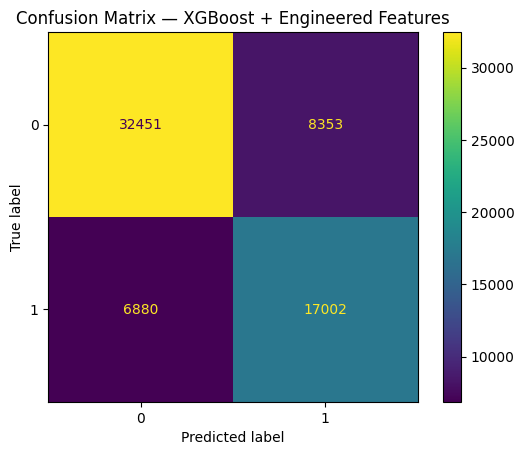

In [35]:
xgb_model_pred = xgb_model.predict(X_valid_boosting)

xgb_model_proba = xgb_model.predict_proba(X_valid_boosting)[:, 1]

xgb_model_metrics = evaluate_binary_classifier(
    model_name=(
        "XGBoost + Engineered Features"
    ),
    y_true=y_valid,
    y_pred=xgb_model_pred,
    y_proba=xgb_model_proba,
)



### Experiment Results

In [36]:
xgb_result_row = {
    "experiment_id": "xgboost_engineered_features",
    "evaluation_split": "validation",
    "feature_set": (
        "14 symmetric lexical and length features + "
        "TF-IDF cosine similarity + "
        "content-word overlap + "
        "weighted content-word overlap"
    ),
    "threshold": 0.5,
    **xgb_model_metrics,
}

current_result = pd.DataFrame(
    [xgb_result_row]
)

In [37]:
os.makedirs(
    os.path.dirname(results_file),
    exist_ok=True,
)

if os.path.exists(results_file):
    model_results = pd.read_csv(
        results_file
    )

    model_results = model_results[
        model_results["experiment_id"]
        != xgb_result_row["experiment_id"]
    ]

    model_results = pd.concat(
        [
            model_results,
            current_result,
        ],
        ignore_index=True,
    )

else:
    model_results = current_result.copy()

model_results.to_csv(
    results_file,
    index=False,
)

print(
    f"Results saved to: {results_file}"
)

Results saved to: /content/drive/MyDrive/ML Projects/quora-duplicate-question-detection/reports/model_results.csv


In [38]:
model_results_display = model_results.copy()

numeric_columns = (
    model_results_display
    .select_dtypes(include="number")
    .columns
)

model_results_display[
    numeric_columns
] = model_results_display[
    numeric_columns
].round(4)

display(
    model_results_display.sort_values(
        by="log_loss"
    )
)

,experiment_id,evaluation_split,feature_set,threshold,model,accuracy,precision,recall,f1,roc_auc,log_loss
1,tfidf_logreg_baseline,validation,TF-IDF word 1-2 grams: absolute difference + e...,0.50,TF-IDF + Logistic Regression,0.8253,0.8005,0.7017,0.7478,0.9039,0.3893
2,xgboost_engineered_features,validation,14 symmetric lexical and length features + TF-...,0.50,XGBoost + Engineered Features,0.7645,0.6706,0.7119,0.6906,0.8534,0.4365
0,bert_mean_pooling_cosine,validation,Mean-pooled bert-base-uncased embeddings + cos...,0.83,BERT Embeddings + Cosine Similarity,0.6513,0.5167,0.8559,0.6444,0.7455,NaN


### XGBoost Conclusions

- The XGBoost model achieved a validation log loss of approximately **0.4365** and a ROC-AUC of approximately **0.85**.
- Adding content-word overlap and frequency-weighted word overlap features substantially improved the boosting model.
- XGBoost achieved slightly higher recall for the duplicate class than Logistic Regression, but its precision, F1-score, ROC-AUC, and log loss were lower.
- TF-IDF with Logistic Regression remained the strongest classical model. The high-dimensional TF-IDF representation preserved more detailed lexical information than the compact set of engineered features used by XGBoost.